In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [ ]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
meal_info = pd.read_csv("../data/meal_info.csv")
center_info = pd.read_csv("../data/fulfilment_center_info.csv")

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Meal info shape:", meal_info.shape)
print("Center info shape:", center_info.shape)

Train shape: (456548, 9)
Test shape: (32573, 8)
Meal info shape: (51, 3)
Center info shape: (77, 5)


In [4]:
print("TRAIN")
display(train.head())

print("TEST")
display(test.head())

print("MEAL INFO")
display(meal_info.head())

print("CENTER INFO")
display(center_info.head())

TRAIN


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


TEST


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured
0,1028232,146,55,1885,158.11,159.11,0,0
1,1127204,146,55,1993,160.11,159.11,0,0
2,1212707,146,55,2539,157.14,159.14,0,0
3,1082698,146,55,2631,162.02,162.02,0,0
4,1400926,146,55,1248,163.93,163.93,0,0


MEAL INFO


,meal_id,category,cuisine
0,1885,Beverages,Thai
1,1993,Beverages,Thai
2,2539,Beverages,Thai
3,1248,Beverages,Indian
4,2631,Beverages,Indian


CENTER INFO


,center_id,city_code,region_code,center_type,op_area
0,11,679,56,TYPE_A,3.7
1,13,590,56,TYPE_B,6.7
2,124,590,56,TYPE_C,4.0
3,66,648,34,TYPE_A,4.1
4,94,632,34,TYPE_C,3.6


In [5]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nMeal info columns:")
print(meal_info.columns.tolist())

print("\nCenter info columns:")
print(center_info.columns.tolist())

Train columns:
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders']

Test columns:
['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']

Meal info columns:
['meal_id', 'category', 'cuisine']

Center info columns:
['center_id', 'city_code', 'region_code', 'center_type', 'op_area']


In [6]:
print("TRAIN DATA TYPES")
display(train.dtypes)

print("\nTEST DATA TYPES")
display(test.dtypes)

print("\nMEAL INFO DATA TYPES")
display(meal_info.dtypes)

print("\nCENTER INFO DATA TYPES")
display(center_info.dtypes)

TRAIN DATA TYPES


id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
dtype: object


TEST DATA TYPES


id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
dtype: object


MEAL INFO DATA TYPES


meal_id      int64
category    object
cuisine     object
dtype: object


CENTER INFO DATA TYPES


center_id        int64
city_code        int64
region_code      int64
center_type     object
op_area        float64
dtype: object

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,456548.0,1.250096e+06,144354.822378,1000000.00,1124998.75,1250183.50,1375140.25,1499999.00
week,456548.0,7.476877e+01,41.524956,1.00,39.00,76.00,111.00,145.00
center_id,456548.0,8.210580e+01,45.975046,10.00,43.00,76.00,110.00,186.00
meal_id,456548.0,2.024337e+03,547.420920,1062.00,1558.00,1993.00,2539.00,2956.00
checkout_price,456548.0,3.322389e+02,152.939723,2.97,228.95,296.82,445.23,866.27
base_price,456548.0,3.541566e+02,160.715914,55.35,243.50,310.46,458.87,866.27
emailer_for_promotion,456548.0,8.115247e-02,0.273069,0.00,0.00,0.00,0.00,1.00
homepage_featured,456548.0,1.091999e-01,0.311890,0.00,0.00,0.00,0.00,1.00
num_orders,456548.0,2.618728e+02,395.922798,13.00,54.00,136.00,324.00,24299.00


In [15]:
train.dtypes


id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
dtype: object

In [16]:
print("Center types:")
print(center_info["center_type"].value_counts())

print("\nMeal categories:")
print(meal_info["category"].value_counts())

print("\nCuisines:")
print(meal_info["cuisine"].value_counts())

Center types:
center_type
TYPE_A    43
TYPE_C    19
TYPE_B    15
Name: count, dtype: int64

Meal categories:
category
Beverages       12
Extras           3
Soup             3
Other Snacks     3
Salad            3
Rice Bowl        3
Starters         3
Sandwich         3
Pasta            3
Desert           3
Biryani          3
Pizza            3
Fish             3
Seafood          3
Name: count, dtype: int64

Cuisines:
cuisine
Thai           15
Indian         12
Italian        12
Continental    12
Name: count, dtype: int64


In [9]:
print("Missing values in TRAIN:")
display(train.isnull().sum())

print("\nMissing values in TEST:")
display(test.isnull().sum())

print("\nMissing values in MEAL INFO:")
display(meal_info.isnull().sum())

print("\nMissing values in CENTER INFO:")
display(center_info.isnull().sum())

Missing values in TRAIN:


id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
dtype: int64


Missing values in TEST:


id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
dtype: int64


Missing values in MEAL INFO:


meal_id     0
category    0
cuisine     0
dtype: int64


Missing values in CENTER INFO:


center_id      0
city_code      0
region_code    0
center_type    0
op_area        0
dtype: int64

In [10]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())
print("Duplicate rows in meal_info:", meal_info.duplicated().sum())
print("Duplicate rows in center_info:", center_info.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0
Duplicate rows in meal_info: 0
Duplicate rows in center_info: 0


In [11]:
print("Minimum week:", train["week"].min())
print("Maximum week:", train["week"].max())

print("\nTest minimum week:", test["week"].min())
print("Test maximum week:", test["week"].max())

Minimum week: 1
Maximum week: 145

Test minimum week: 146
Test maximum week: 155


In [12]:
print("Unique centers:", train["center_id"].nunique())
print("Unique meals:", train["meal_id"].nunique())
print("Unique weeks:", train["week"].nunique())

Unique centers: 77
Unique meals: 51
Unique weeks: 145


In [13]:
print("Center IDs:", train["center_id"].unique())
print("\nNumber of center types:", center_info["center_type"].nunique())
print("Center types:", center_info["center_type"].unique())

print("\nMeal categories:")
print(meal_info["category"].unique())

print("\nCuisines:")
print(meal_info["cuisine"].unique())

Center IDs: [ 55  24  11  83  32  13 109  52  93 186 146  57 149  89 124 152  97  74
 108  99  66  94  91  20  34 137  92 126  36 162  75 177  27 157 106  64
 129  14  17 153 139 161  81  26  73  50 104  42 113 145  53  72  67 174
  29  77  41  30  76  59  88 143  58  10 101  80  43  65  39 102 110 132
  23  86  68  51  61]

Number of center types: 3
Center types: ['TYPE_A' 'TYPE_B' 'TYPE_C']

Meal categories:
['Beverages' 'Extras' 'Soup' 'Other Snacks' 'Salad' 'Rice Bowl' 'Starters'
 'Sandwich' 'Pasta' 'Desert' 'Biryani' 'Pizza' 'Fish' 'Seafood']

Cuisines:
['Thai' 'Indian' 'Italian' 'Continental']


In [14]:
expected_weeks = set(range(train["week"].min(), train["week"].max() + 1))
actual_weeks = set(train["week"].unique())

missing_weeks = expected_weeks - actual_weeks

print("Missing weeks:", sorted(missing_weeks))

Missing weeks: []


## Target Variable Analysis

In [17]:
train["num_orders"].describe()

count    456548.000000
mean        261.872760
std         395.922798
min          13.000000
25%          54.000000
50%         136.000000
75%         324.000000
max       24299.000000
Name: num_orders, dtype: float64

In [18]:
print("Skewness:", train["num_orders"].skew())
print("Kurtosis:", train["num_orders"].kurtosis())

Skewness: 6.929966065342181
Kurtosis: 121.852219624065


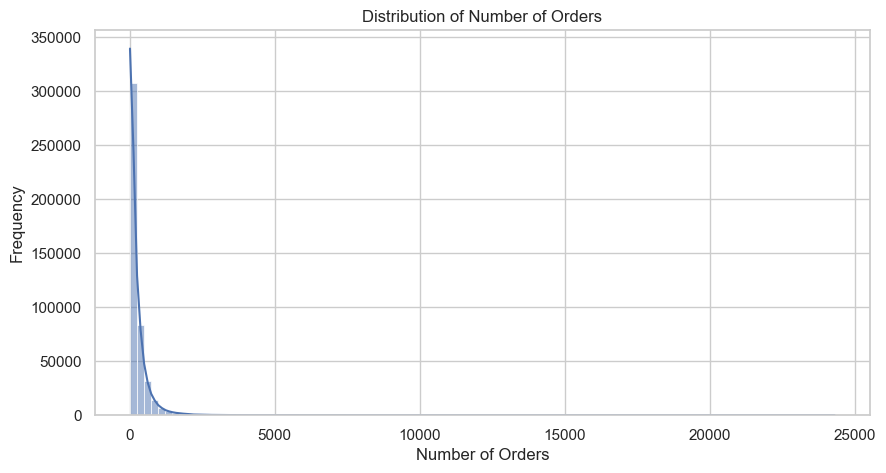

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(train["num_orders"], bins=100, kde=True)

plt.title("Distribution of Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")
plt.show()

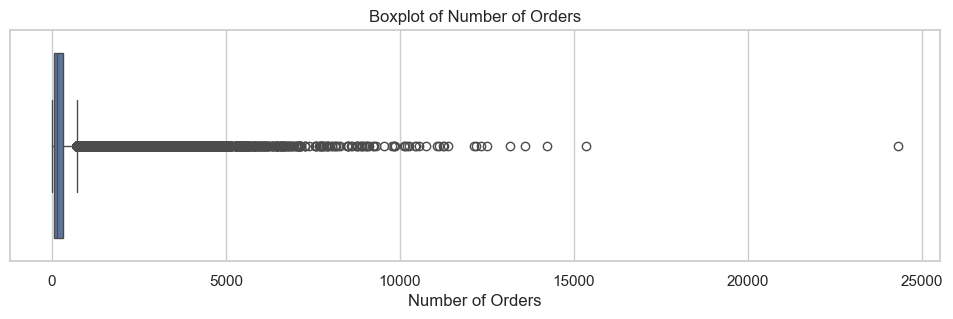

In [20]:
plt.figure(figsize=(12, 3))

sns.boxplot(x=train["num_orders"])

plt.title("Boxplot of Number of Orders")
plt.xlabel("Number of Orders")
plt.show()

In [21]:
print("Top 20 highest order values:")
display(
    train[["id", "week", "center_id", "meal_id", "num_orders"]]
    .sort_values("num_orders", ascending=False)
    .head(20)
)

Top 20 highest order values:


,id,week,center_id,meal_id,num_orders
14050,1452474,5,43,2290,24299
19700,1300512,7,43,2290,15336
16904,1087163,6,43,2290,14229
13923,1470267,5,10,2290,13580
413351,1346216,132,43,1971,13150
12068,1352978,5,89,2290,12489
90857,1238452,32,146,1754,12327
12509,1091831,5,137,2290,12177
12300,1002009,5,99,2290,12137
85371,1398441,30,126,1754,11380


In [ ]:

weekly_orders = (
    train.groupby("week")["num_orders"]
    .sum()
    .reset_index()
)

weekly_orders.head()

,week,num_orders
0,1,792261
1,2,787084
2,3,695262
3,4,743529
4,5,1198675


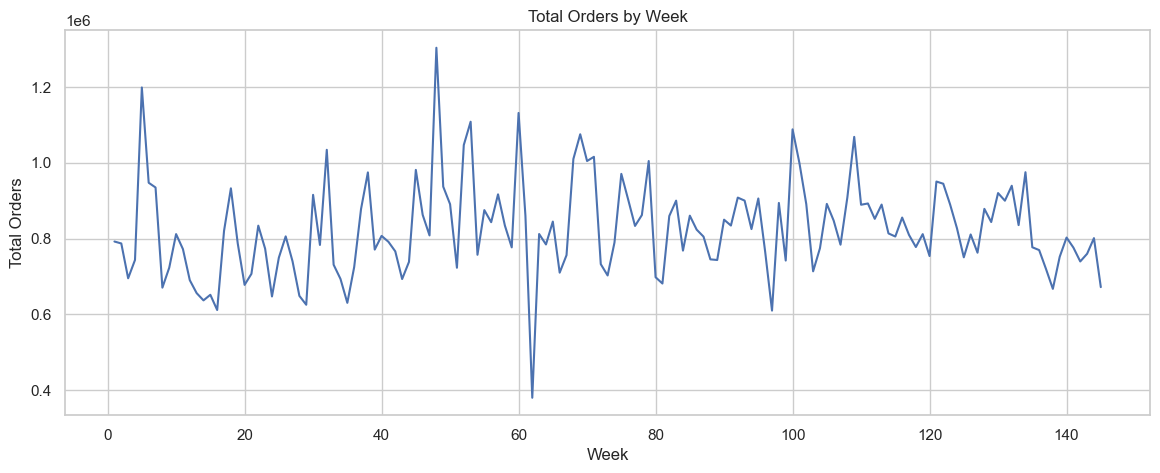

In [23]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=weekly_orders,
    x="week",
    y="num_orders"
)

plt.title("Total Orders by Week")
plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.show()

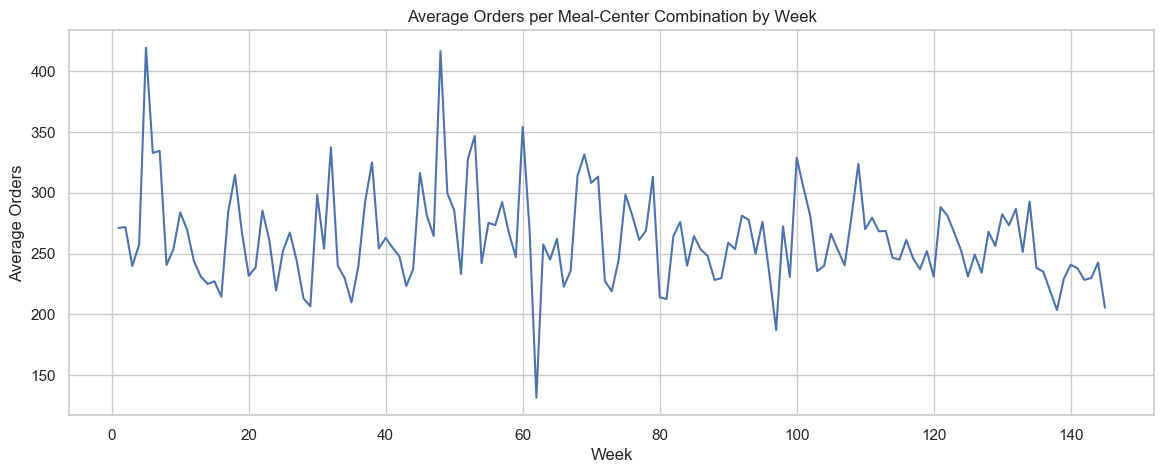

In [24]:
# Average orders per meal-center combination by week
weekly_avg_orders = (
    train.groupby("week")["num_orders"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=weekly_avg_orders,
    x="week",
    y="num_orders"
)

plt.title("Average Orders per Meal-Center Combination by Week")
plt.xlabel("Week")
plt.ylabel("Average Orders")
plt.show()

In [25]:
weekly_stats = (
    train.groupby("week")["num_orders"]
    .agg(["sum", "mean", "median", "min", "max"])
    .reset_index()
)

display(weekly_stats.head(10))

,week,sum,mean,median,min,max
0,1,792261,271.136550,150.0,13,3511
1,2,787084,271.783149,163.0,13,2606
2,3,695262,239.828217,136.0,13,2526
3,4,743529,257.365524,149.0,13,3172
4,5,1198675,419.263729,148.0,13,24299
5,6,947288,332.848911,136.0,13,14229
6,7,934803,334.455456,122.0,13,15336
7,8,670518,240.674085,95.0,13,4779
8,9,723243,253.413805,149.5,13,2538
9,10,811825,283.954180,161.0,13,3309


In [26]:
weekly_orders["rolling_mean_10"] = (
    weekly_orders["num_orders"]
    .rolling(window=10)
    .mean()
)

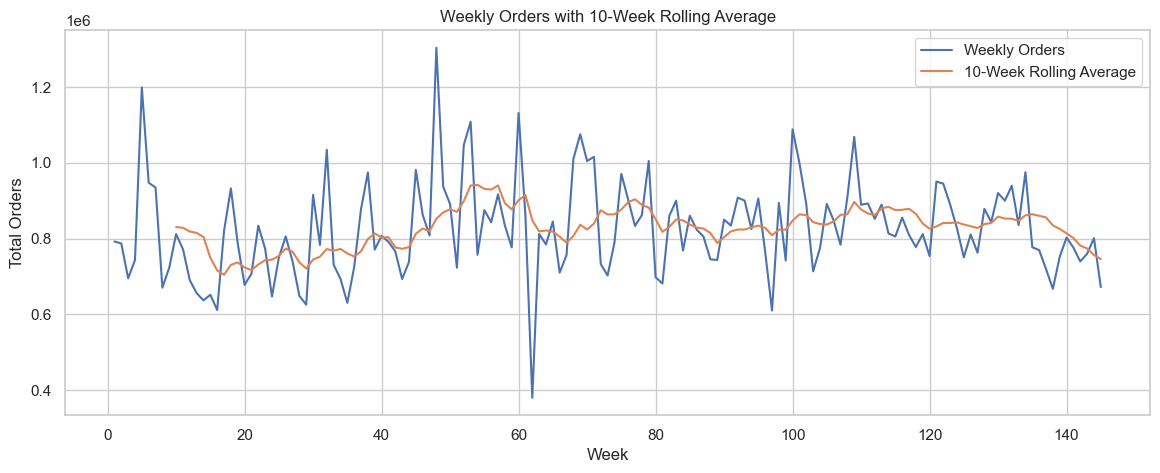

In [27]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=weekly_orders,
    x="week",
    y="num_orders",
    label="Weekly Orders"
)

sns.lineplot(
    data=weekly_orders,
    x="week",
    y="rolling_mean_10",
    label="10-Week Rolling Average"
)

plt.title("Weekly Orders with 10-Week Rolling Average")
plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.legend()
plt.show()

In [28]:
first_10_avg = weekly_orders.loc[
    weekly_orders["week"] <= 10, "num_orders"
].mean()

last_10_avg = weekly_orders.loc[
    weekly_orders["week"] >= 136, "num_orders"
].mean()

print("Average orders in first 10 weeks:", round(first_10_avg, 2))
print("Average orders in last 10 weeks:", round(last_10_avg, 2))
print(
    "Percentage change:",
    round((last_10_avg - first_10_avg) / first_10_avg * 100, 2),
    "%"
)

Average orders in first 10 weeks: 830448.8
Average orders in last 10 weeks: 746028.0
Percentage change: -10.17 %
